# CheMeleon adaptive model regression

In [1]:
!pip install rdkit==2025.3.3
!pip install chemprop==2.2.1
!pip install matplotlib

In [11]:
import random
from random import sample, seed, shuffle
import numpy as np
import pandas as pd
import os
import six
from rdkit import rdBase
from rdkit import RDLogger

# Suppress RDKit warnings
rdBase.DisableLog('rdApp.*')
RDLogger.DisableLog('rdApp.*')

#utility functions : prepare the data
from model_fp_selection.lib.utils import prepare_df_morgan, prepare_df_rdkit, swap_identical_ligands, prepare_df_chemeleon, convert_to_float, prepare_df
from model_fp_selection.lib.utils import drop_duplicates, average_duplicates, calc_desc, get_ligands_dict

#utility functions : CV and results
from model_fp_selection.lib.utils import obtain_metrics, plot_cv_results
from model_fp_selection.lib.utils import df_split, get_indices_doi, get_indices_scaff, get_indices_chemeleon, get_indices_chemeleon_DOI, get_indices_chemeleon_scaff
from model_fp_selection.lib.utils import generate_scaffold, scaffold_to_smiles
from model_fp_selection.lib.utils import ligands_permutation, cross_validation, prepare_train_set, cross_validation_chemeleon


from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs, Draw
from sklearn.model_selection import KFold, GridSearchCV, train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, median_absolute_error, PredictionErrorDisplay
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_validate
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.preprocessing import MinMaxScaler

#Encoding categorical Data
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.preprocessing import StandardScaler

# Regressors
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor

#Pipelines and other model constructions
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer

# Visualization
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 20})

#np.random.seed(42)
#seed(42)

#Specific to Scaffold Splitting
from rdkit.Chem.Scaffolds import MurckoScaffold
from collections import defaultdict
import pickle as pkl
import time
from tqdm import tqdm
#import seaborn as sns

from itertools import *

#from model_fp_selection.lib.cross_val_both_models import cross_val_2_models

from model_fp_selection.chemeleon_fingerprint import CheMeleonFingerprint

from pathlib import Path

from lightning import pytorch as pl

from lightning.pytorch.callbacks import ModelCheckpoint
import pandas as pd

import torch.nn as torch_nn

from chemprop import data, models, featurizers, nn

import time

import lightning.pytorch as pl
from lightning.pytorch.callbacks import Callback
import torch

import tempfile

## Preparing the dataset

In [3]:
df_input = pd.read_csv("./ruthenium_complexes_dataset.csv")

df_input = prepare_df(df_input)
df_input = average_duplicates(df_input, 'Ligands_Tuple', 'pIC50')

df_input.reset_index(drop=True, inplace=True)

# Build SMILES
df_input['SMILES'] = df_input['L1'] + '.' + df_input['L2'] + '.' + df_input['L3']

smiles_column = "SMILES"
target_column = "pIC50"

smis = df_input[smiles_column].values
ys = df_input[[target_column]].values

all_data = [
    data.MoleculeDatapoint.from_smi(smi, y)
    for smi, y in zip(smis, ys)
]

Length of training dataset after cleaning duplicates, before adding permutations : 715


In [10]:
# For reproducibility

pl.seed_everything(42, workers=True)

torch.use_deterministic_algorithms(True)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


## Random split

In [5]:
indices = get_indices_chemeleon(df_input, shuffle=True)

train length : 578 val length : 65 | test length : 72
train length : 578 val length : 65 | test length : 72
train length : 578 val length : 65 | test length : 72
train length : 578 val length : 65 | test length : 72
train length : 578 val length : 65 | test length : 72
train length : 579 val length : 65 | test length : 71
train length : 579 val length : 65 | test length : 71
train length : 579 val length : 65 | test length : 71
train length : 579 val length : 65 | test length : 71
train length : 579 val length : 65 | test length : 71


INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


CV iteration 0


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loading `train_dataloader` to estimate number of stepping batches.
INFO:lightning.pytorch.utilit

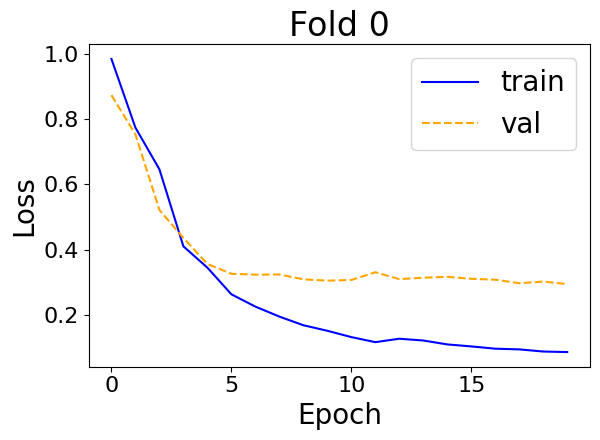

INFO: Restoring states from the checkpoint path at /tmp/tmpmd4kmq2t/epoch=19-step=200.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /tmp/tmpmd4kmq2t/epoch=19-step=200.ckpt
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loaded model weights from the checkpoint at /tmp/tmpmd4kmq2t/epoch=19-step=200.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Loaded model weights from the checkpoint at /tmp/tmpmd4kmq2t/epoch=19-step=200.ckpt
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO: Restoring states from the checkpoint path at /tmp/tmpmd4kmq2t/epoch=19-step=200.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /tmp/tmpmd4kmq2t/epoch=19-step=200.ckpt
INFO: LOCAL_RA

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/mae          │    0.31445661187171936    │
│          test/r2          │    0.7691977620124817     │
│         test/rmse         │    0.4377811849117279     │
└───────────────────────────┴───────────────────────────┘

INFO: Seed set to 43
INFO:lightning.fabric.utilities.seed:Seed set to 43
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loading `train_dataload

CV iteration 1


/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO: `Trainer.fit` stopped: `max_epochs=20` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.


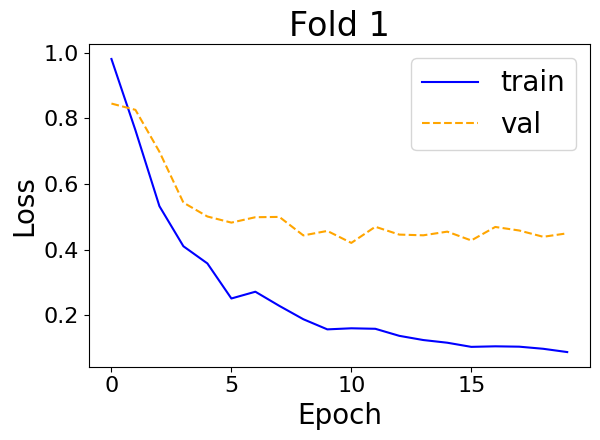

INFO: Restoring states from the checkpoint path at /tmp/tmpajzz6wip/epoch=10-step=110.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /tmp/tmpajzz6wip/epoch=10-step=110.ckpt
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loaded model weights from the checkpoint at /tmp/tmpajzz6wip/epoch=10-step=110.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Loaded model weights from the checkpoint at /tmp/tmpajzz6wip/epoch=10-step=110.ckpt
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO: Restoring states from the checkpoint path at /tmp/tmpajzz6wip/epoch=10-step=110.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /tmp/tmpajzz6wip/epoch=10-step=110.ckpt
INFO: LOCAL_RA

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/mae          │    0.3352871537208557     │
│          test/r2          │    0.7162463665008545     │
│         test/rmse         │     0.442506343126297     │
└───────────────────────────┴───────────────────────────┘

INFO: Seed set to 44
INFO:lightning.fabric.utilities.seed:Seed set to 44
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loading `train_dataload

CV iteration 2


/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO: `Trainer.fit` stopped: `max_epochs=20` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.


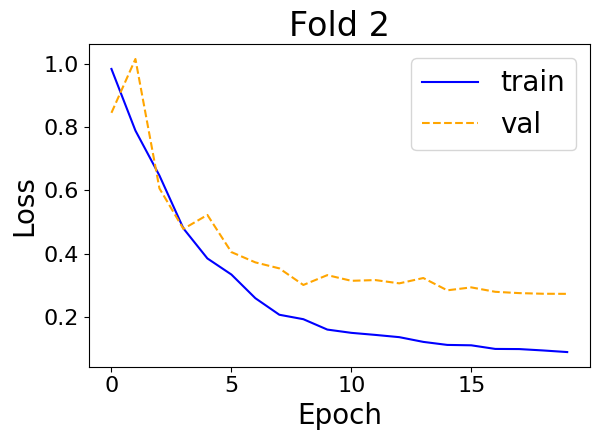

INFO: Restoring states from the checkpoint path at /tmp/tmp_rzaj6cr/epoch=19-step=200.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /tmp/tmp_rzaj6cr/epoch=19-step=200.ckpt
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loaded model weights from the checkpoint at /tmp/tmp_rzaj6cr/epoch=19-step=200.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Loaded model weights from the checkpoint at /tmp/tmp_rzaj6cr/epoch=19-step=200.ckpt
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO: Restoring states from the checkpoint path at /tmp/tmp_rzaj6cr/epoch=19-step=200.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /tmp/tmp_rzaj6cr/epoch=19-step=200.ckpt
INFO: LOCAL_RA

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/mae          │    0.38037940859794617    │
│          test/r2          │    0.6645458340644836     │
│         test/rmse         │    0.5208304524421692     │
└───────────────────────────┴───────────────────────────┘

INFO: Seed set to 45
INFO:lightning.fabric.utilities.seed:Seed set to 45
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loading `train_dataload

CV iteration 3


/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO: `Trainer.fit` stopped: `max_epochs=20` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.


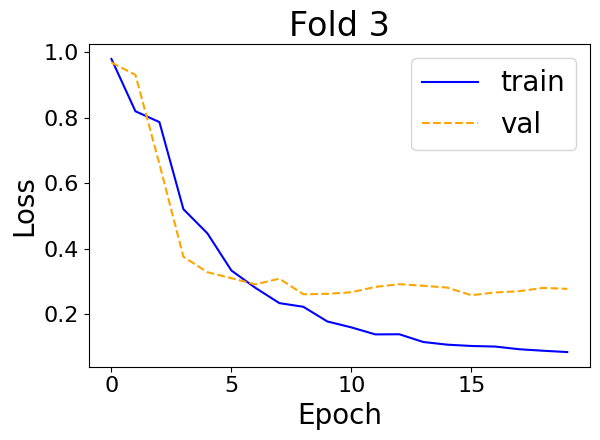

INFO: Restoring states from the checkpoint path at /tmp/tmpq85mfeb6/epoch=15-step=160.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /tmp/tmpq85mfeb6/epoch=15-step=160.ckpt
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loaded model weights from the checkpoint at /tmp/tmpq85mfeb6/epoch=15-step=160.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Loaded model weights from the checkpoint at /tmp/tmpq85mfeb6/epoch=15-step=160.ckpt
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO: Restoring states from the checkpoint path at /tmp/tmpq85mfeb6/epoch=15-step=160.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /tmp/tmpq85mfeb6/epoch=15-step=160.ckpt
INFO: LOCAL_RA

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/mae          │    0.3012937009334564     │
│          test/r2          │     0.800478458404541     │
│         test/rmse         │    0.40355855226516724    │
└───────────────────────────┴───────────────────────────┘

INFO: Seed set to 46
INFO:lightning.fabric.utilities.seed:Seed set to 46


CV iteration 4


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loading `train_dataloader` to estimate number of stepping batches.
INFO:lightning.pytorch.utilit

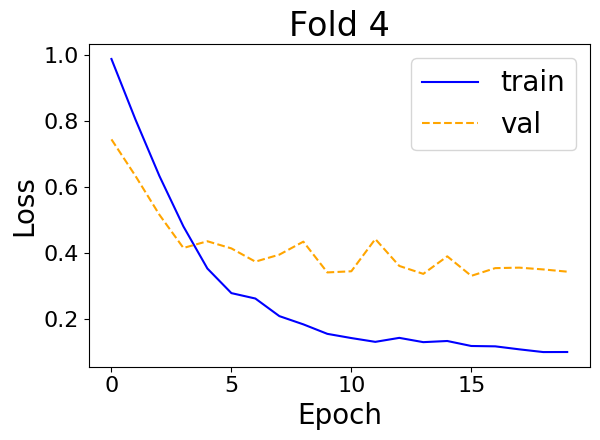

INFO: Restoring states from the checkpoint path at /tmp/tmp5af3y3qq/epoch=15-step=160.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /tmp/tmp5af3y3qq/epoch=15-step=160.ckpt
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loaded model weights from the checkpoint at /tmp/tmp5af3y3qq/epoch=15-step=160.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Loaded model weights from the checkpoint at /tmp/tmp5af3y3qq/epoch=15-step=160.ckpt
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO: Restoring states from the checkpoint path at /tmp/tmp5af3y3qq/epoch=15-step=160.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /tmp/tmp5af3y3qq/epoch=15-step=160.ckpt
INFO: LOCAL_RA

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/mae          │    0.32864823937416077    │
│          test/r2          │    0.5479843616485596     │
│         test/rmse         │    0.45602473616600037    │
└───────────────────────────┴───────────────────────────┘

INFO: Seed set to 47
INFO:lightning.fabric.utilities.seed:Seed set to 47


CV iteration 5


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loading `train_dataloader` to estimate number of stepping batches.
INFO:lightning.pytorch.utilit

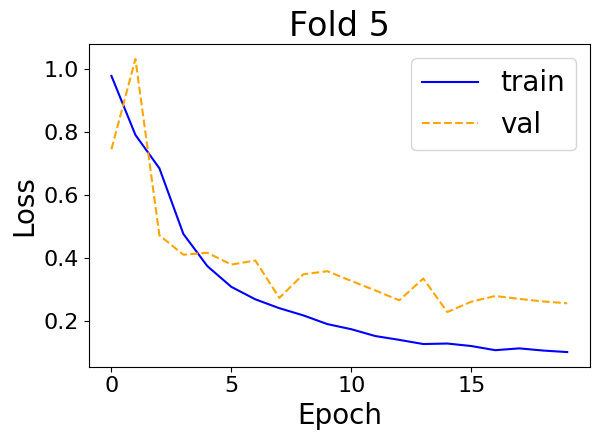

INFO: Restoring states from the checkpoint path at /tmp/tmppdd5kerx/epoch=14-step=150.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /tmp/tmppdd5kerx/epoch=14-step=150.ckpt
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loaded model weights from the checkpoint at /tmp/tmppdd5kerx/epoch=14-step=150.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Loaded model weights from the checkpoint at /tmp/tmppdd5kerx/epoch=14-step=150.ckpt
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO: Restoring states from the checkpoint path at /tmp/tmppdd5kerx/epoch=14-step=150.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /tmp/tmppdd5kerx/epoch=14-step=150.ckpt
INFO: LOCAL_RA

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/mae          │      0.2873555123806      │
│          test/r2          │    0.7194823026657104     │
│         test/rmse         │    0.3849140405654907     │
└───────────────────────────┴───────────────────────────┘

INFO: Seed set to 48
INFO:lightning.fabric.utilities.seed:Seed set to 48


CV iteration 6


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loading `train_dataloader` to estimate number of stepping batches.
INFO:lightning.pytorch.utilit

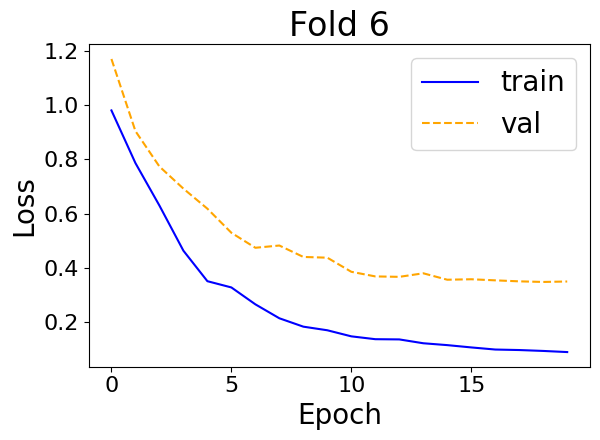

INFO: Restoring states from the checkpoint path at /tmp/tmpkwz7xj93/epoch=18-step=190.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /tmp/tmpkwz7xj93/epoch=18-step=190.ckpt
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loaded model weights from the checkpoint at /tmp/tmpkwz7xj93/epoch=18-step=190.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Loaded model weights from the checkpoint at /tmp/tmpkwz7xj93/epoch=18-step=190.ckpt
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO: Restoring states from the checkpoint path at /tmp/tmpkwz7xj93/epoch=18-step=190.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /tmp/tmpkwz7xj93/epoch=18-step=190.ckpt
INFO: LOCAL_RA

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/mae          │    0.3617497980594635     │
│          test/r2          │    0.6153746843338013     │
│         test/rmse         │    0.5222834348678589     │
└───────────────────────────┴───────────────────────────┘

INFO: Seed set to 49
INFO:lightning.fabric.utilities.seed:Seed set to 49
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loading `train_dataload

CV iteration 7


/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO: `Trainer.fit` stopped: `max_epochs=20` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.


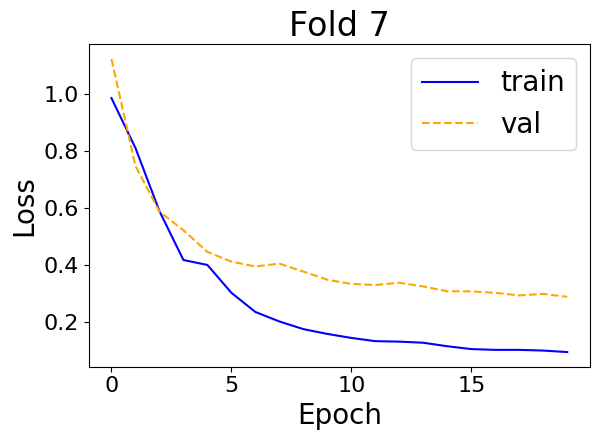

INFO: Restoring states from the checkpoint path at /tmp/tmp94ap6qav/epoch=19-step=200.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /tmp/tmp94ap6qav/epoch=19-step=200.ckpt
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loaded model weights from the checkpoint at /tmp/tmp94ap6qav/epoch=19-step=200.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Loaded model weights from the checkpoint at /tmp/tmp94ap6qav/epoch=19-step=200.ckpt
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO: Restoring states from the checkpoint path at /tmp/tmp94ap6qav/epoch=19-step=200.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /tmp/tmp94ap6qav/epoch=19-step=200.ckpt
INFO: LOCAL_RA

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/mae          │    0.40259847044944763    │
│          test/r2          │    0.5026072263717651     │
│         test/rmse         │    0.5161404013633728     │
└───────────────────────────┴───────────────────────────┘

INFO: Seed set to 50
INFO:lightning.fabric.utilities.seed:Seed set to 50
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loading `train_dataload

CV iteration 8


/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO: `Trainer.fit` stopped: `max_epochs=20` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.


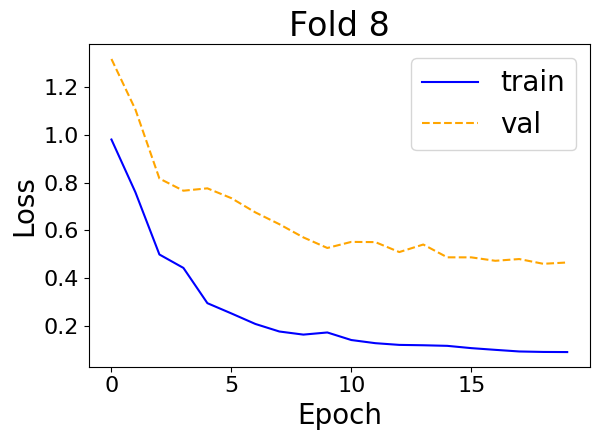

INFO: Restoring states from the checkpoint path at /tmp/tmpbv3vgoq9/epoch=18-step=190.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /tmp/tmpbv3vgoq9/epoch=18-step=190.ckpt
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loaded model weights from the checkpoint at /tmp/tmpbv3vgoq9/epoch=18-step=190.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Loaded model weights from the checkpoint at /tmp/tmpbv3vgoq9/epoch=18-step=190.ckpt
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO: Restoring states from the checkpoint path at /tmp/tmpbv3vgoq9/epoch=18-step=190.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /tmp/tmpbv3vgoq9/epoch=18-step=190.ckpt
INFO: LOCAL_RA

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/mae          │    0.32466405630111694    │
│          test/r2          │    0.7457073926925659     │
│         test/rmse         │    0.4361002445220947     │
└───────────────────────────┴───────────────────────────┘

INFO: Seed set to 51
INFO:lightning.fabric.utilities.seed:Seed set to 51
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loading `train_dataload

CV iteration 9


/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO: `Trainer.fit` stopped: `max_epochs=20` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.


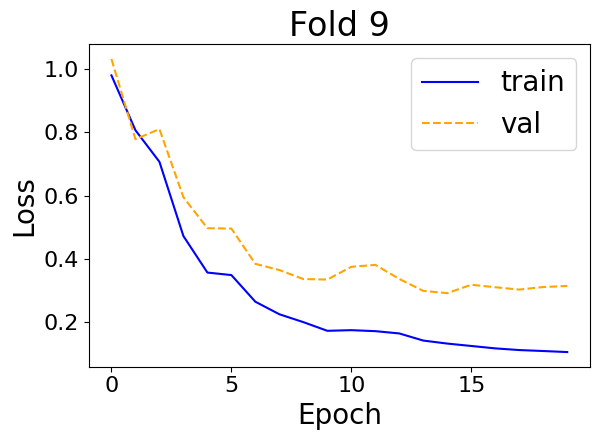

INFO: Restoring states from the checkpoint path at /tmp/tmps3j3mh_s/epoch=14-step=150.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /tmp/tmps3j3mh_s/epoch=14-step=150.ckpt
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loaded model weights from the checkpoint at /tmp/tmps3j3mh_s/epoch=14-step=150.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Loaded model weights from the checkpoint at /tmp/tmps3j3mh_s/epoch=14-step=150.ckpt
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO: Restoring states from the checkpoint path at /tmp/tmps3j3mh_s/epoch=14-step=150.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /tmp/tmps3j3mh_s/epoch=14-step=150.ckpt
INFO: LOCAL_RA

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/mae          │    0.49208950996398926    │
│          test/r2          │    0.3392757773399353     │
│         test/rmse         │    0.6697038412094116     │
└───────────────────────────┴───────────────────────────┘

Total training time: 1594.83 seconds (26.58 minutes)
{'MAE': 0.3527065128743661, 'RMSE': np.float64(0.48512883086556646), 'Ratio': np.float64(1.3754461943785232), 'R² Score': 0.6604061728873577}


In [6]:
y_data, y_pred = cross_validation_chemeleon(all_data, indices)

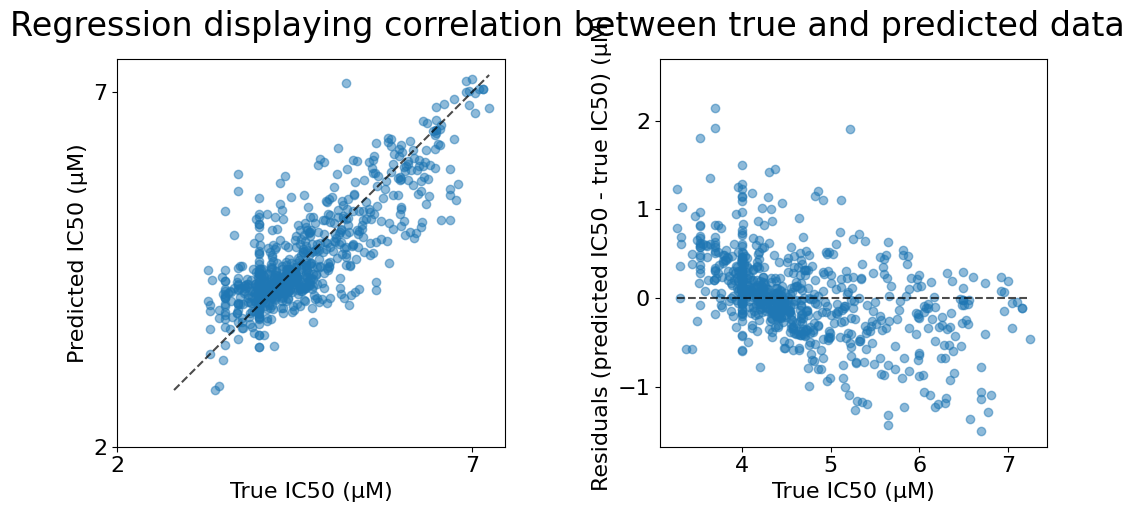

In [7]:
plot_cv_results(y_data, y_pred)

## DOI split

In [8]:
indices_doi = get_indices_chemeleon_DOI(df_input, CV=10)

train DOIs : 176 | val DOIs : 19 | test DOIs : 22
train length : 565 | val length : 57 | test length : 93
train DOIs : 176 | val DOIs : 19 | test DOIs : 22
train length : 580 | val length : 59 | test length : 76
train DOIs : 176 | val DOIs : 19 | test DOIs : 22
train length : 566 | val length : 62 | test length : 87
train DOIs : 176 | val DOIs : 19 | test DOIs : 22
train length : 587 | val length : 48 | test length : 80
train DOIs : 176 | val DOIs : 19 | test DOIs : 22
train length : 547 | val length : 92 | test length : 76
train DOIs : 176 | val DOIs : 19 | test DOIs : 22
train length : 603 | val length : 40 | test length : 72
train DOIs : 176 | val DOIs : 19 | test DOIs : 22
train length : 597 | val length : 60 | test length : 58
train DOIs : 176 | val DOIs : 20 | test DOIs : 21
train length : 584 | val length : 63 | test length : 68
train DOIs : 176 | val DOIs : 20 | test DOIs : 21
train length : 597 | val length : 64 | test length : 54
train DOIs : 176 | val DOIs : 20 | test DOIs :

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


CV iteration 0


INFO: Loading `train_dataloader` to estimate number of stepping batches.
INFO:lightning.pytorch.utilities.rank_zero:Loading `train_dataloader` to estimate number of stepping batches.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO: `Trainer.fit` stopped: `max_epochs=20` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.


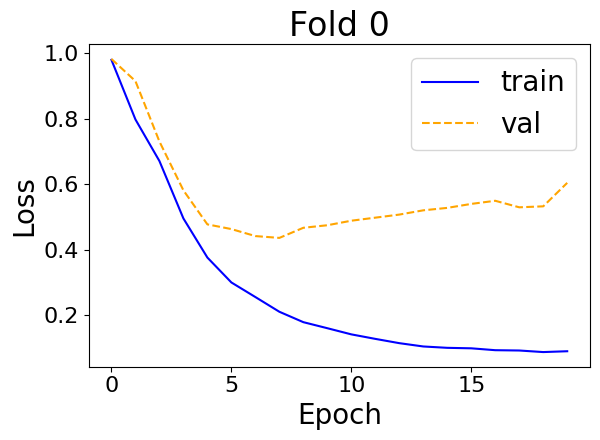

INFO: Restoring states from the checkpoint path at /tmp/tmp6vopcldq/epoch=7-step=72.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /tmp/tmp6vopcldq/epoch=7-step=72.ckpt
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loaded model weights from the checkpoint at /tmp/tmp6vopcldq/epoch=7-step=72.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Loaded model weights from the checkpoint at /tmp/tmp6vopcldq/epoch=7-step=72.ckpt
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO: Restoring states from the checkpoint path at /tmp/tmp6vopcldq/epoch=7-step=72.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /tmp/tmp6vopcldq/epoch=7-step=72.ckpt
INFO: LOCAL_RANK: 0 - CUDA

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/mae          │    0.7214656472206116     │
│          test/r2          │    0.4251493811607361     │
│         test/rmse         │    0.8909875154495239     │
└───────────────────────────┴───────────────────────────┘

INFO: Seed set to 43
INFO:lightning.fabric.utilities.seed:Seed set to 43
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loading `train_dataload

CV iteration 1


/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO: `Trainer.fit` stopped: `max_epochs=20` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.


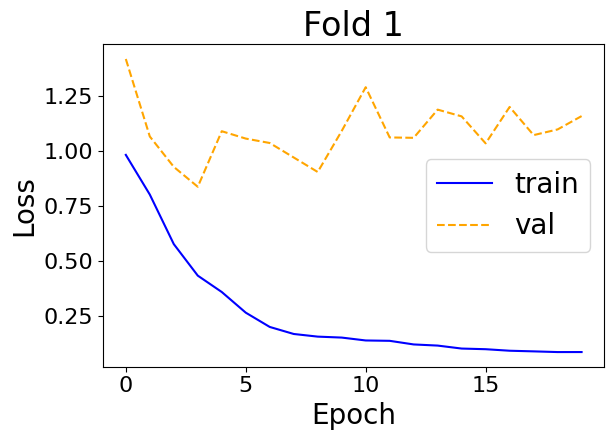

INFO: Restoring states from the checkpoint path at /tmp/tmp8ebwbfvf/epoch=3-step=40.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /tmp/tmp8ebwbfvf/epoch=3-step=40.ckpt
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loaded model weights from the checkpoint at /tmp/tmp8ebwbfvf/epoch=3-step=40.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Loaded model weights from the checkpoint at /tmp/tmp8ebwbfvf/epoch=3-step=40.ckpt
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO: Restoring states from the checkpoint path at /tmp/tmp8ebwbfvf/epoch=3-step=40.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /tmp/tmp8ebwbfvf/epoch=3-step=40.ckpt
INFO: LOCAL_RANK: 0 - CUDA

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/mae          │    0.4004839360713959     │
│          test/r2          │    0.4912155270576477     │
│         test/rmse         │    0.5365425944328308     │
└───────────────────────────┴───────────────────────────┘

INFO: Seed set to 44
INFO:lightning.fabric.utilities.seed:Seed set to 44
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loading `train_dataload

CV iteration 2


/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO: `Trainer.fit` stopped: `max_epochs=20` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.


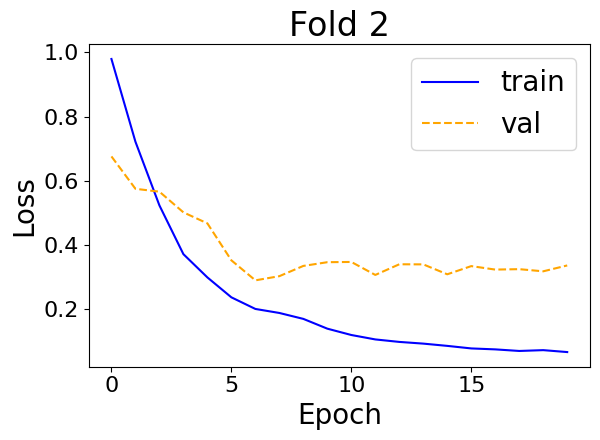

INFO: Restoring states from the checkpoint path at /tmp/tmpc28bvhmg/epoch=6-step=63.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /tmp/tmpc28bvhmg/epoch=6-step=63.ckpt
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loaded model weights from the checkpoint at /tmp/tmpc28bvhmg/epoch=6-step=63.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Loaded model weights from the checkpoint at /tmp/tmpc28bvhmg/epoch=6-step=63.ckpt
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO: Restoring states from the checkpoint path at /tmp/tmpc28bvhmg/epoch=6-step=63.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /tmp/tmpc28bvhmg/epoch=6-step=63.ckpt
INFO: LOCAL_RANK: 0 - CUDA

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/mae          │    0.5396662950515747     │
│          test/r2          │    0.2945646047592163     │
│         test/rmse         │    0.7074105739593506     │
└───────────────────────────┴───────────────────────────┘

INFO: Seed set to 45
INFO:lightning.fabric.utilities.seed:Seed set to 45


CV iteration 3


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loading `train_dataloader` to estimate number of stepping batches.
INFO:lightning.pytorch.utilit

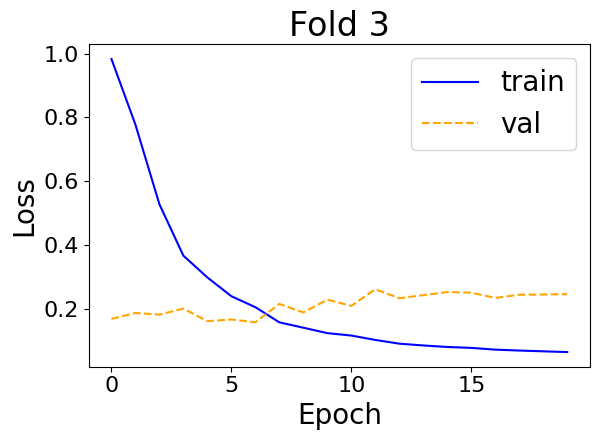

INFO: Restoring states from the checkpoint path at /tmp/tmpt2ekbns1/epoch=6-step=70.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /tmp/tmpt2ekbns1/epoch=6-step=70.ckpt
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loaded model weights from the checkpoint at /tmp/tmpt2ekbns1/epoch=6-step=70.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Loaded model weights from the checkpoint at /tmp/tmpt2ekbns1/epoch=6-step=70.ckpt
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO: Restoring states from the checkpoint path at /tmp/tmpt2ekbns1/epoch=6-step=70.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /tmp/tmpt2ekbns1/epoch=6-step=70.ckpt
INFO: LOCAL_RANK: 0 - CUDA

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/mae          │    0.4586498737335205     │
│          test/r2          │   -0.13135743141174316    │
│         test/rmse         │    0.5900841951370239     │
└───────────────────────────┴───────────────────────────┘

INFO: Seed set to 46
INFO:lightning.fabric.utilities.seed:Seed set to 46
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loading `train_dataload

CV iteration 4


/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO: `Trainer.fit` stopped: `max_epochs=20` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.


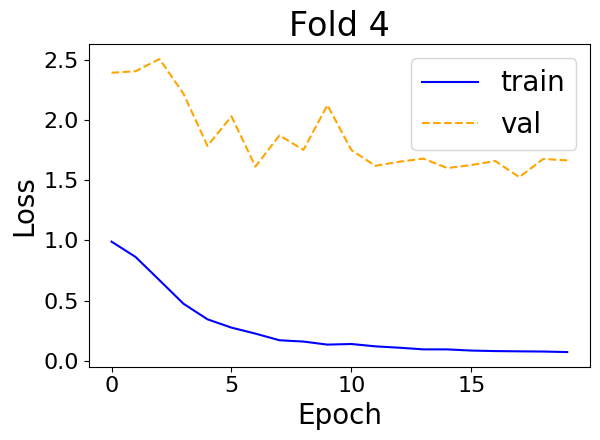

INFO: Restoring states from the checkpoint path at /tmp/tmpz7v4v_pm/epoch=17-step=162.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /tmp/tmpz7v4v_pm/epoch=17-step=162.ckpt
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loaded model weights from the checkpoint at /tmp/tmpz7v4v_pm/epoch=17-step=162.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Loaded model weights from the checkpoint at /tmp/tmpz7v4v_pm/epoch=17-step=162.ckpt
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO: Restoring states from the checkpoint path at /tmp/tmpz7v4v_pm/epoch=17-step=162.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /tmp/tmpz7v4v_pm/epoch=17-step=162.ckpt
INFO: LOCAL_RA

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/mae          │    0.31168437004089355    │
│          test/r2          │     0.656916081905365     │
│         test/rmse         │    0.39500105381011963    │
└───────────────────────────┴───────────────────────────┘

INFO: Seed set to 47
INFO:lightning.fabric.utilities.seed:Seed set to 47
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loading `train_dataload

CV iteration 5


/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO: `Trainer.fit` stopped: `max_epochs=20` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.


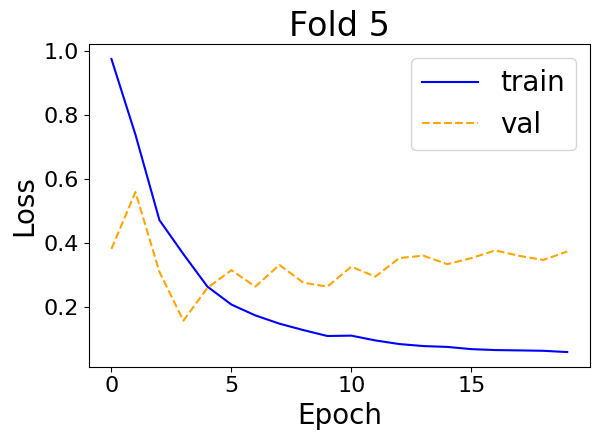

INFO: Restoring states from the checkpoint path at /tmp/tmpwai_yab2/epoch=3-step=40.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /tmp/tmpwai_yab2/epoch=3-step=40.ckpt
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loaded model weights from the checkpoint at /tmp/tmpwai_yab2/epoch=3-step=40.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Loaded model weights from the checkpoint at /tmp/tmpwai_yab2/epoch=3-step=40.ckpt
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO: Restoring states from the checkpoint path at /tmp/tmpwai_yab2/epoch=3-step=40.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /tmp/tmpwai_yab2/epoch=3-step=40.ckpt
INFO: LOCAL_RANK: 0 - CUDA

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/mae          │    0.48385095596313477    │
│          test/r2          │    -0.2727276086807251    │
│         test/rmse         │    0.6328082084655762     │
└───────────────────────────┴───────────────────────────┘

INFO: Seed set to 48
INFO:lightning.fabric.utilities.seed:Seed set to 48


CV iteration 6


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loading `train_dataloader` to estimate number of stepping batches.
INFO:lightning.pytorch.utilit

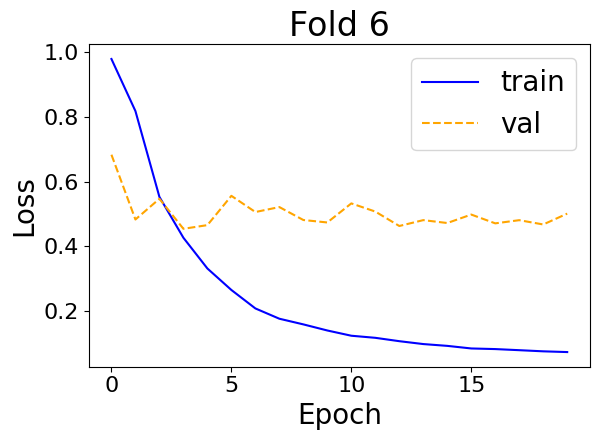

INFO: Restoring states from the checkpoint path at /tmp/tmpfjrflcd5/epoch=3-step=40.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /tmp/tmpfjrflcd5/epoch=3-step=40.ckpt
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loaded model weights from the checkpoint at /tmp/tmpfjrflcd5/epoch=3-step=40.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Loaded model weights from the checkpoint at /tmp/tmpfjrflcd5/epoch=3-step=40.ckpt
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO: Restoring states from the checkpoint path at /tmp/tmpfjrflcd5/epoch=3-step=40.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /tmp/tmpfjrflcd5/epoch=3-step=40.ckpt
INFO: LOCAL_RANK: 0 - CUDA

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/mae          │    0.4451294541358948     │
│          test/r2          │   -0.11313176155090332    │
│         test/rmse         │    0.5770437121391296     │
└───────────────────────────┴───────────────────────────┘

INFO: Seed set to 49
INFO:lightning.fabric.utilities.seed:Seed set to 49
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loading `train_dataload

CV iteration 7


/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO: `Trainer.fit` stopped: `max_epochs=20` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.


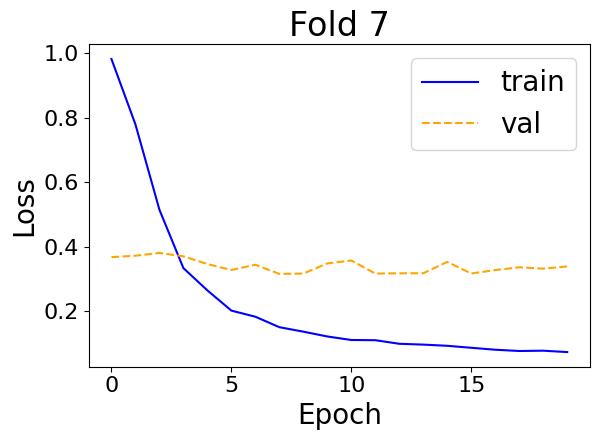

INFO: Restoring states from the checkpoint path at /tmp/tmpculrw94i/epoch=7-step=80.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /tmp/tmpculrw94i/epoch=7-step=80.ckpt
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loaded model weights from the checkpoint at /tmp/tmpculrw94i/epoch=7-step=80.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Loaded model weights from the checkpoint at /tmp/tmpculrw94i/epoch=7-step=80.ckpt
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO: Restoring states from the checkpoint path at /tmp/tmpculrw94i/epoch=7-step=80.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /tmp/tmpculrw94i/epoch=7-step=80.ckpt
INFO: LOCAL_RANK: 0 - CUDA

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/mae          │    0.5795319676399231     │
│          test/r2          │    0.43868201971054077    │
│         test/rmse         │    0.7573540210723877     │
└───────────────────────────┴───────────────────────────┘

INFO: Seed set to 50
INFO:lightning.fabric.utilities.seed:Seed set to 50
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loading `train_dataload

CV iteration 8


/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO: `Trainer.fit` stopped: `max_epochs=20` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.


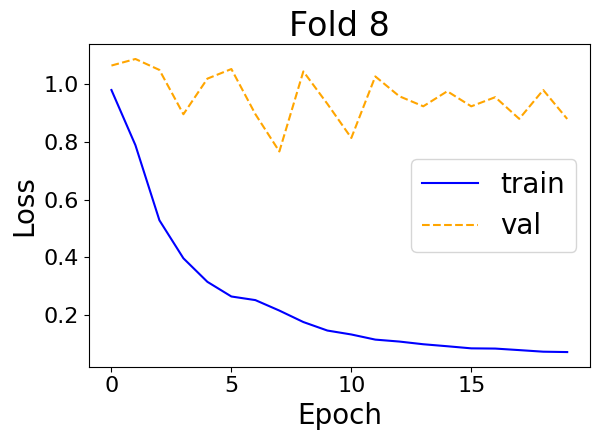

INFO: Restoring states from the checkpoint path at /tmp/tmpy6gd77gd/epoch=7-step=80.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /tmp/tmpy6gd77gd/epoch=7-step=80.ckpt
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loaded model weights from the checkpoint at /tmp/tmpy6gd77gd/epoch=7-step=80.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Loaded model weights from the checkpoint at /tmp/tmpy6gd77gd/epoch=7-step=80.ckpt
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO: Restoring states from the checkpoint path at /tmp/tmpy6gd77gd/epoch=7-step=80.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /tmp/tmpy6gd77gd/epoch=7-step=80.ckpt
INFO: LOCAL_RANK: 0 - CUDA

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/mae          │    0.5099053978919983     │
│          test/r2          │    0.3428354263305664     │
│         test/rmse         │    0.6623573899269104     │
└───────────────────────────┴───────────────────────────┘

INFO: Seed set to 51
INFO:lightning.fabric.utilities.seed:Seed set to 51
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loading `train_dataload

CV iteration 9


/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO: `Trainer.fit` stopped: `max_epochs=20` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.


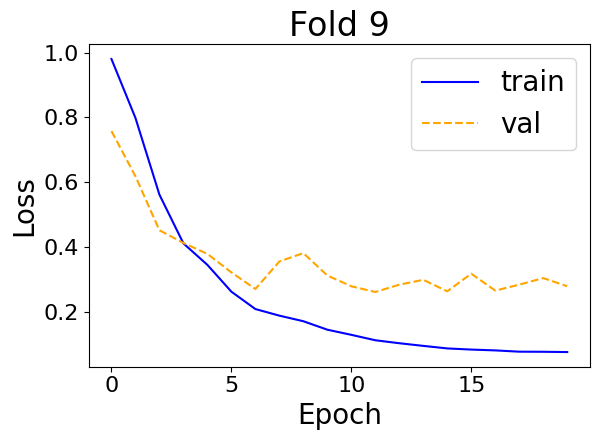

INFO: Restoring states from the checkpoint path at /tmp/tmp8fqb3jra/epoch=11-step=120.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /tmp/tmp8fqb3jra/epoch=11-step=120.ckpt
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loaded model weights from the checkpoint at /tmp/tmp8fqb3jra/epoch=11-step=120.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Loaded model weights from the checkpoint at /tmp/tmp8fqb3jra/epoch=11-step=120.ckpt
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO: Restoring states from the checkpoint path at /tmp/tmp8fqb3jra/epoch=11-step=120.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /tmp/tmp8fqb3jra/epoch=11-step=120.ckpt
INFO: LOCAL_RA

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/mae          │    0.46988385915756226    │
│          test/r2          │    0.06194096803665161    │
│         test/rmse         │    0.6441223621368408     │
└───────────────────────────┴───────────────────────────┘

Total training time: 1575.48 seconds (26.26 minutes)
{'MAE': 0.4984978724605383, 'RMSE': np.float64(0.6594741793672207), 'Ratio': np.float64(1.3229227561436092), 'R² Score': 0.3724602950491105}


In [9]:
y_data, y_pred = cross_validation_chemeleon(all_data, indices_doi)

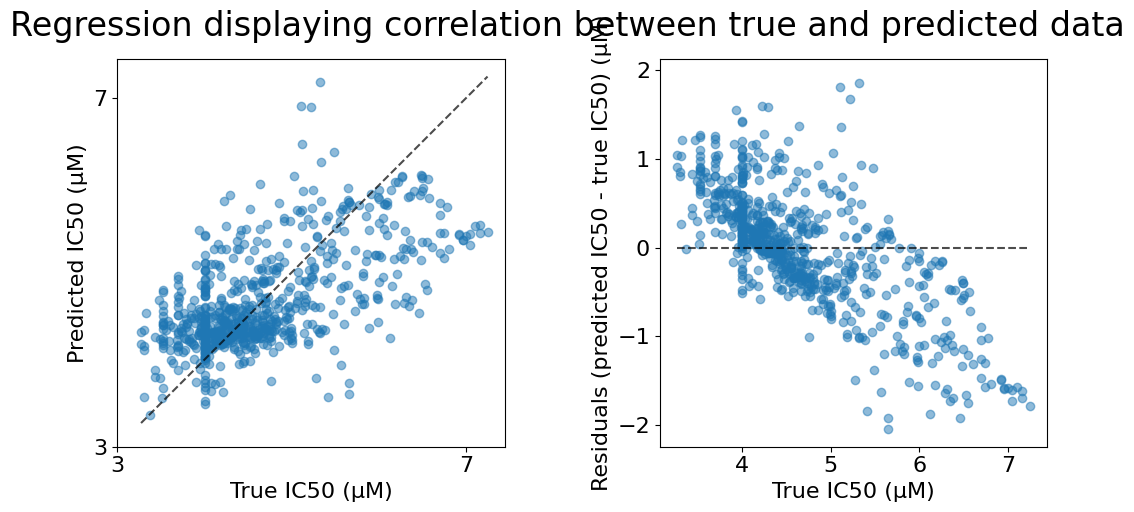

In [10]:
plot_cv_results(y_data, y_pred)

## Scaffold split

In [6]:
df_input['MOL3'] = df_input['L3'].apply(Chem.MolFromSmiles)
molsB = df_input['MOL3'].tolist()

In [7]:
indices_scaff_B = get_indices_chemeleon_scaff(molsB, 10, seeder=0)

100%|██████████| 715/715 [00:00<00:00, 4478.32it/s]

train length : 541, scaffolds : 162 | val length : 128, scaffolds : 18 | test length : 46, scaffolds : 20
train length : 512, scaffolds : 162 | val length : 135, scaffolds : 18 | test length : 68, scaffolds : 20
train length : 532, scaffolds : 162 | val length : 138, scaffolds : 18 | test length : 45, scaffolds : 20
train length : 535, scaffolds : 162 | val length : 37, scaffolds : 18 | test length : 143, scaffolds : 20
train length : 620, scaffolds : 162 | val length : 56, scaffolds : 18 | test length : 39, scaffolds : 20
train length : 609, scaffolds : 162 | val length : 54, scaffolds : 18 | test length : 52, scaffolds : 20
train length : 589, scaffolds : 162 | val length : 67, scaffolds : 18 | test length : 59, scaffolds : 20
train length : 443, scaffolds : 162 | val length : 126, scaffolds : 18 | test length : 146, scaffolds : 20
train length : 579, scaffolds : 162 | val length : 86, scaffolds : 18 | test length : 50, scaffolds : 20
train length : 542, scaffolds : 162 | val length 

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


CV iteration 0


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loading `train_dataloader` to estimate number of stepping batches.
INFO:lightning.pytorch.utilit

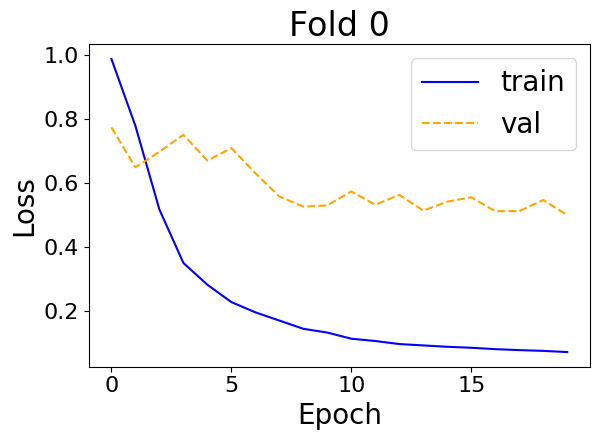

INFO: Restoring states from the checkpoint path at /tmp/tmp_6x3khoe/epoch=19-step=180.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /tmp/tmp_6x3khoe/epoch=19-step=180.ckpt
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loaded model weights from the checkpoint at /tmp/tmp_6x3khoe/epoch=19-step=180.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Loaded model weights from the checkpoint at /tmp/tmp_6x3khoe/epoch=19-step=180.ckpt
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO: Restoring states from the checkpoint path at /tmp/tmp_6x3khoe/epoch=19-step=180.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /tmp/tmp_6x3khoe/epoch=19-step=180.ckpt
INFO: LOCAL_RA

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/mae          │    0.33707305788993835    │
│          test/r2          │    0.5232926607131958     │
│         test/rmse         │    0.4699689447879791     │
└───────────────────────────┴───────────────────────────┘

INFO: Seed set to 43
INFO:lightning.fabric.utilities.seed:Seed set to 43
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


CV iteration 1


INFO: Loading `train_dataloader` to estimate number of stepping batches.
INFO:lightning.pytorch.utilities.rank_zero:Loading `train_dataloader` to estimate number of stepping batches.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO: `Trainer.fit` stopped: `max_epochs=20` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.


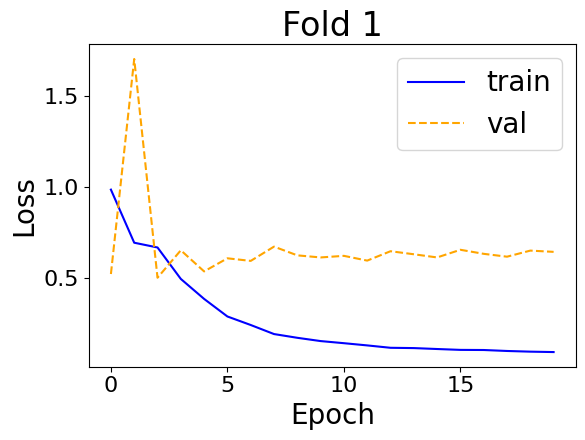

INFO: Restoring states from the checkpoint path at /tmp/tmpcg_27fmg/epoch=2-step=24.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /tmp/tmpcg_27fmg/epoch=2-step=24.ckpt
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loaded model weights from the checkpoint at /tmp/tmpcg_27fmg/epoch=2-step=24.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Loaded model weights from the checkpoint at /tmp/tmpcg_27fmg/epoch=2-step=24.ckpt
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO: Restoring states from the checkpoint path at /tmp/tmpcg_27fmg/epoch=2-step=24.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /tmp/tmpcg_27fmg/epoch=2-step=24.ckpt
INFO: LOCAL_RANK: 0 - CUDA

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/mae          │    0.7491694092750549     │
│          test/r2          │    -0.3440309762954712    │
│         test/rmse         │    0.9585922360420227     │
└───────────────────────────┴───────────────────────────┘

INFO: Seed set to 44
INFO:lightning.fabric.utilities.seed:Seed set to 44
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loading `train_dataload

CV iteration 2


/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO: `Trainer.fit` stopped: `max_epochs=20` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.


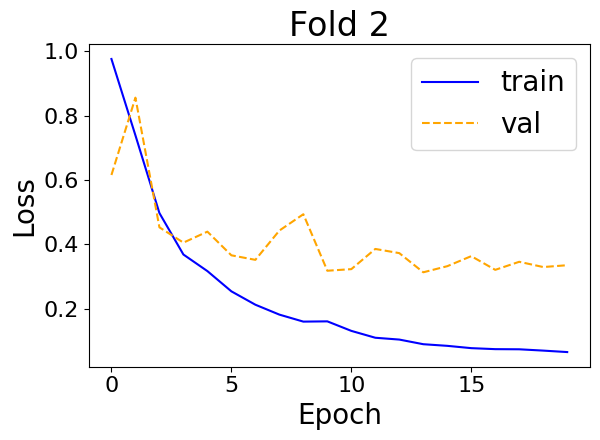

INFO: Restoring states from the checkpoint path at /tmp/tmpbd38r42o/epoch=13-step=126.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /tmp/tmpbd38r42o/epoch=13-step=126.ckpt
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loaded model weights from the checkpoint at /tmp/tmpbd38r42o/epoch=13-step=126.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Loaded model weights from the checkpoint at /tmp/tmpbd38r42o/epoch=13-step=126.ckpt
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO: Restoring states from the checkpoint path at /tmp/tmpbd38r42o/epoch=13-step=126.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /tmp/tmpbd38r42o/epoch=13-step=126.ckpt
INFO: LOCAL_RA

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/mae          │    0.4728730022907257     │
│          test/r2          │    0.44856804609298706    │
│         test/rmse         │    0.6028353571891785     │
└───────────────────────────┴───────────────────────────┘

INFO: Seed set to 45
INFO:lightning.fabric.utilities.seed:Seed set to 45
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loading `train_dataload

CV iteration 3


/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO: `Trainer.fit` stopped: `max_epochs=20` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.


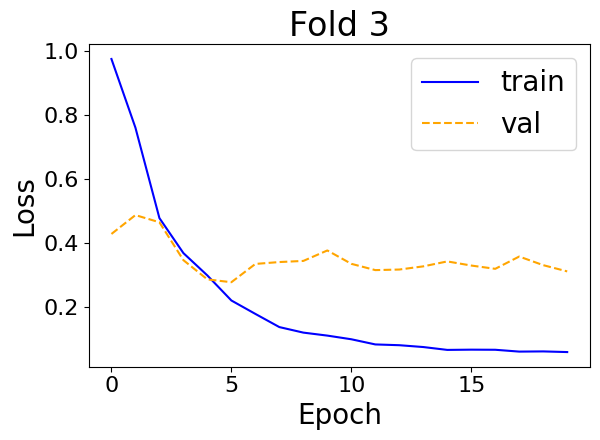

INFO: Restoring states from the checkpoint path at /tmp/tmphciruf7c/epoch=5-step=54.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /tmp/tmphciruf7c/epoch=5-step=54.ckpt
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loaded model weights from the checkpoint at /tmp/tmphciruf7c/epoch=5-step=54.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Loaded model weights from the checkpoint at /tmp/tmphciruf7c/epoch=5-step=54.ckpt
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO: Restoring states from the checkpoint path at /tmp/tmphciruf7c/epoch=5-step=54.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /tmp/tmphciruf7c/epoch=5-step=54.ckpt
INFO: LOCAL_RANK: 0 - CUDA

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/mae          │    0.35067903995513916    │
│          test/r2          │    0.2803732752799988     │
│         test/rmse         │     0.470388263463974     │
└───────────────────────────┴───────────────────────────┘

INFO: Seed set to 46
INFO:lightning.fabric.utilities.seed:Seed set to 46


CV iteration 4


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loading `train_dataloader` to estimate number of stepping batches.
INFO:lightning.pytorch.utilit

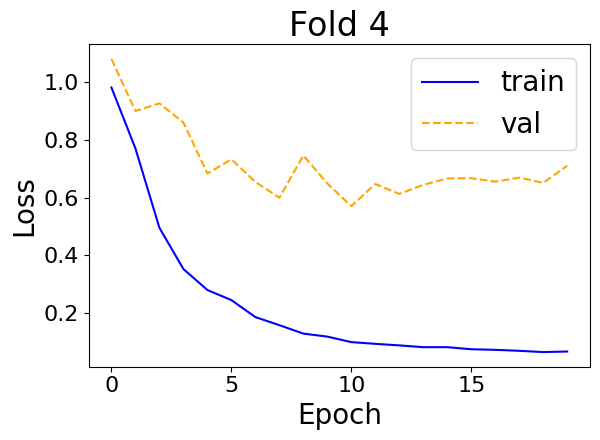

INFO: Restoring states from the checkpoint path at /tmp/tmpz_gmre5v/epoch=10-step=110.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /tmp/tmpz_gmre5v/epoch=10-step=110.ckpt
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loaded model weights from the checkpoint at /tmp/tmpz_gmre5v/epoch=10-step=110.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Loaded model weights from the checkpoint at /tmp/tmpz_gmre5v/epoch=10-step=110.ckpt
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO: Restoring states from the checkpoint path at /tmp/tmpz_gmre5v/epoch=10-step=110.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /tmp/tmpz_gmre5v/epoch=10-step=110.ckpt
INFO: LOCAL_RA

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/mae          │    0.5981529355049133     │
│          test/r2          │    0.2849254012107849     │
│         test/rmse         │    0.8276993632316589     │
└───────────────────────────┴───────────────────────────┘

INFO: Seed set to 47
INFO:lightning.fabric.utilities.seed:Seed set to 47
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loading `train_dataload

CV iteration 5


/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO: `Trainer.fit` stopped: `max_epochs=20` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.


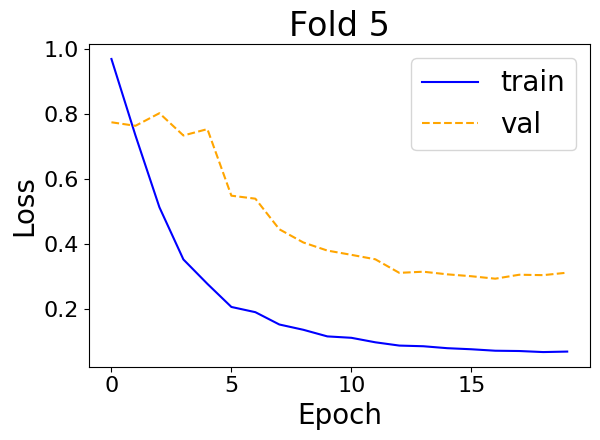

INFO: Restoring states from the checkpoint path at /tmp/tmp73izywwd/epoch=16-step=170.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /tmp/tmp73izywwd/epoch=16-step=170.ckpt
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loaded model weights from the checkpoint at /tmp/tmp73izywwd/epoch=16-step=170.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Loaded model weights from the checkpoint at /tmp/tmp73izywwd/epoch=16-step=170.ckpt
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO: Restoring states from the checkpoint path at /tmp/tmp73izywwd/epoch=16-step=170.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /tmp/tmp73izywwd/epoch=16-step=170.ckpt
INFO: LOCAL_RA

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/mae          │    0.4980096220970154     │
│          test/r2          │    0.3028692603111267     │
│         test/rmse         │    0.5954617261886597     │
└───────────────────────────┴───────────────────────────┘

INFO: Seed set to 48
INFO:lightning.fabric.utilities.seed:Seed set to 48
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loading `train_dataload

CV iteration 6


/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO: `Trainer.fit` stopped: `max_epochs=20` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.


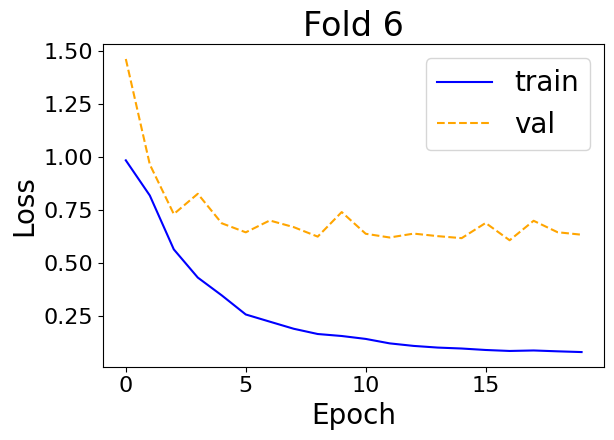

INFO: Restoring states from the checkpoint path at /tmp/tmpp72d76pm/epoch=16-step=170.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /tmp/tmpp72d76pm/epoch=16-step=170.ckpt
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loaded model weights from the checkpoint at /tmp/tmpp72d76pm/epoch=16-step=170.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Loaded model weights from the checkpoint at /tmp/tmpp72d76pm/epoch=16-step=170.ckpt
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO: Restoring states from the checkpoint path at /tmp/tmpp72d76pm/epoch=16-step=170.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /tmp/tmpp72d76pm/epoch=16-step=170.ckpt
INFO: LOCAL_RA

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/mae          │    0.4417491853237152     │
│          test/r2          │    0.3171117901802063     │
│         test/rmse         │    0.6325123310089111     │
└───────────────────────────┴───────────────────────────┘

INFO: Seed set to 49
INFO:lightning.fabric.utilities.seed:Seed set to 49
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loading `train_dataload

CV iteration 7


/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO: `Trainer.fit` stopped: `max_epochs=20` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.


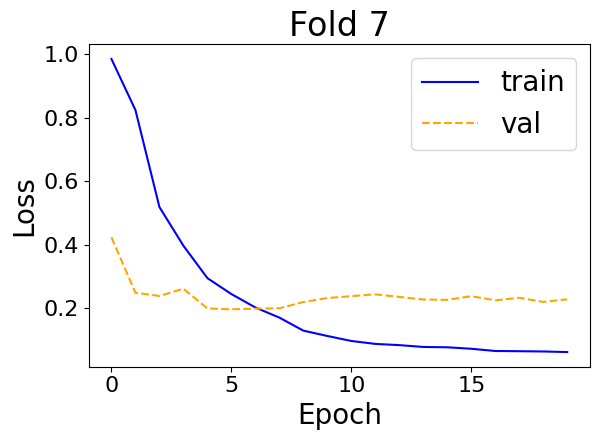

INFO: Restoring states from the checkpoint path at /tmp/tmp1zt6ye7n/epoch=5-step=42.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /tmp/tmp1zt6ye7n/epoch=5-step=42.ckpt
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loaded model weights from the checkpoint at /tmp/tmp1zt6ye7n/epoch=5-step=42.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Loaded model weights from the checkpoint at /tmp/tmp1zt6ye7n/epoch=5-step=42.ckpt
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO: Restoring states from the checkpoint path at /tmp/tmp1zt6ye7n/epoch=5-step=42.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /tmp/tmp1zt6ye7n/epoch=5-step=42.ckpt
INFO: LOCAL_RANK: 0 - CUDA

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/mae          │    0.44528234004974365    │
│          test/r2          │    0.08501625061035156    │
│         test/rmse         │    0.5571114420890808     │
└───────────────────────────┴───────────────────────────┘

INFO: Seed set to 50
INFO:lightning.fabric.utilities.seed:Seed set to 50
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loading `train_dataload

CV iteration 8


/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO: `Trainer.fit` stopped: `max_epochs=20` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.


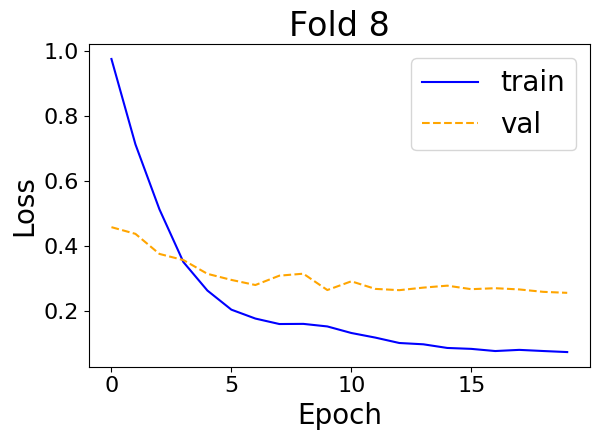

INFO: Restoring states from the checkpoint path at /tmp/tmpq2q3w5hd/epoch=19-step=200.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /tmp/tmpq2q3w5hd/epoch=19-step=200.ckpt
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loaded model weights from the checkpoint at /tmp/tmpq2q3w5hd/epoch=19-step=200.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Loaded model weights from the checkpoint at /tmp/tmpq2q3w5hd/epoch=19-step=200.ckpt
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO: Restoring states from the checkpoint path at /tmp/tmpq2q3w5hd/epoch=19-step=200.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /tmp/tmpq2q3w5hd/epoch=19-step=200.ckpt
INFO: LOCAL_RA

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/mae          │    0.49540475010871887    │
│          test/r2          │    -0.2796286344528198    │
│         test/rmse         │     0.713417649269104     │
└───────────────────────────┴───────────────────────────┘

INFO: Seed set to 51
INFO:lightning.fabric.utilities.seed:Seed set to 51
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loading `train_dataload

CV iteration 9


/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO: `Trainer.fit` stopped: `max_epochs=20` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.


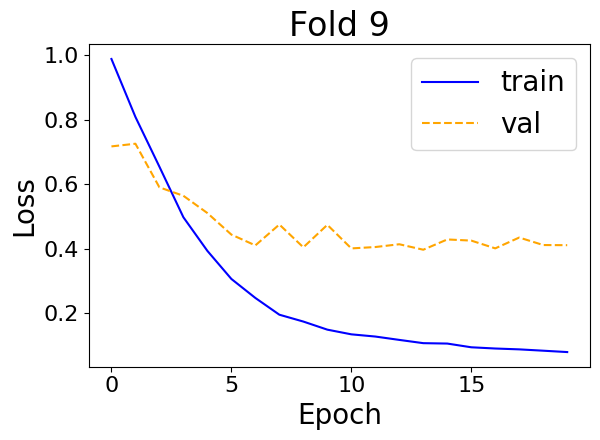

INFO: Restoring states from the checkpoint path at /tmp/tmp2ba1tl52/epoch=13-step=126.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /tmp/tmp2ba1tl52/epoch=13-step=126.ckpt
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loaded model weights from the checkpoint at /tmp/tmp2ba1tl52/epoch=13-step=126.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Loaded model weights from the checkpoint at /tmp/tmp2ba1tl52/epoch=13-step=126.ckpt
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO: Restoring states from the checkpoint path at /tmp/tmp2ba1tl52/epoch=13-step=126.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /tmp/tmp2ba1tl52/epoch=13-step=126.ckpt
INFO: LOCAL_RA

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/mae          │    0.6223889589309692     │
│          test/r2          │     0.625565767288208     │
│         test/rmse         │    0.7538147568702698     │
└───────────────────────────┴───────────────────────────┘

Total training time: 1579.27 seconds (26.32 minutes)
{'MAE': 0.4820202303466694, 'RMSE': np.float64(0.6458416158385952), 'Ratio': np.float64(1.339864128470511), 'R² Score': 0.39813696746862426}


In [8]:
y_data_scaff_B, y_predictions_scaff_B = cross_validation_chemeleon(all_data, indices_scaff_B)

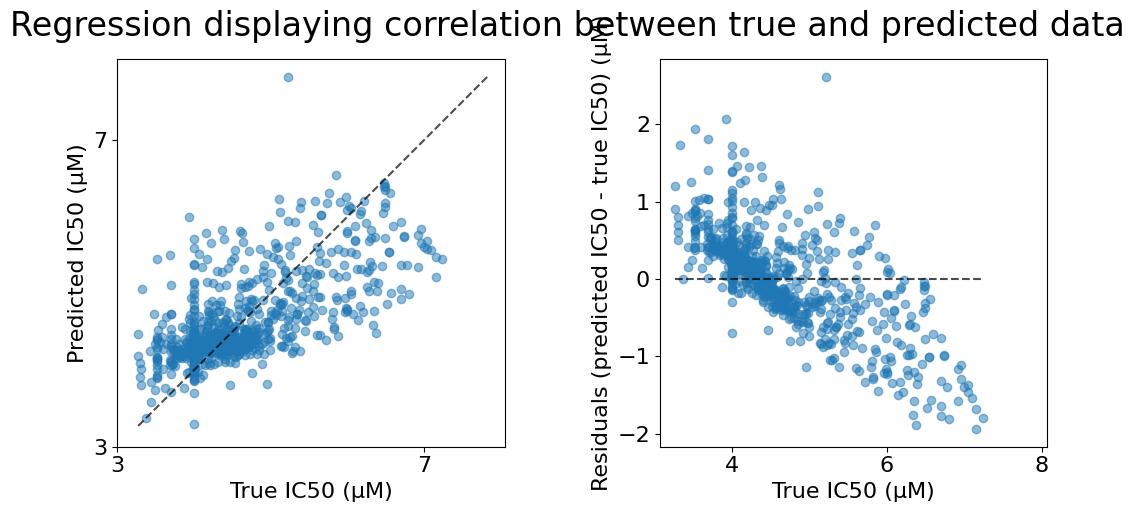

In [14]:
plot_cv_results(y_data_scaff_B, y_predictions_scaff_B)